## Homework 02
---
Tópicos abordados:
- Imagem Integral e Binarização Adaptativa de Imagens

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


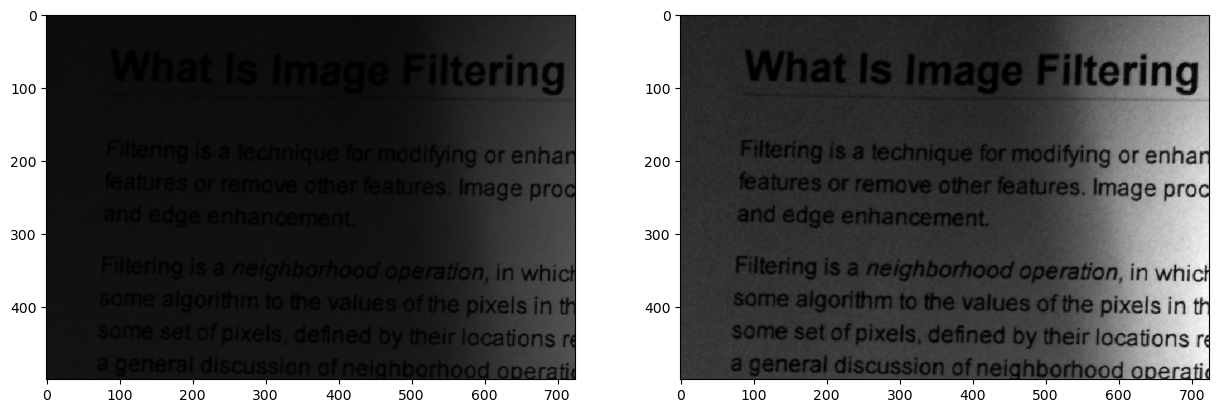

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt


fname = "images/doc-roi.png"
# fname = "images/rice.png"
# fname = "images/lena.ppm"
# fname = "images/coloredChips.png"

rgb = cv.cvtColor( cv.imread( fname ), cv.COLOR_BGR2RGB);
gray = cv.cvtColor(rgb, cv.COLOR_RGB2GRAY);

fig_imref = plt.figure( figsize=(15,10) )
plt.subplot(121);
plt.imshow(rgb);
plt.subplot(122);
plt.imshow(gray, cmap="gray");

### Questão 01) **Imagem Integral e Binarização Adaptativa**

Implemente, em Python, o conceito de imagem integral como uma função e a utilize para calcular de forma eficiente a soma dos pixels de qualquer região retangular de uma imagem.

Considere uma imagem em tons de cinza representada por uma matriz \(I\). A imagem integral \(S\) é definida de modo que cada posição contenha a soma de todos os pixels localizados acima e à esquerda daquela posição:

$$ S(x,y)=\sum_{i=0}^{x}\sum_{j=0}^{y} I(i,j) $$

A partir da imagem integral, a soma dos pixels de uma região retangular pode ser obtida utilizando apenas quatro acessos à matriz, independentemente do tamanho da região.


**a)** Crie uma função que calcule a imagem integral de uma imagem em escala de cinza. Apresente as imagens integral da imagem de referência e do quadrado ponto a ponto da imagem de referência.

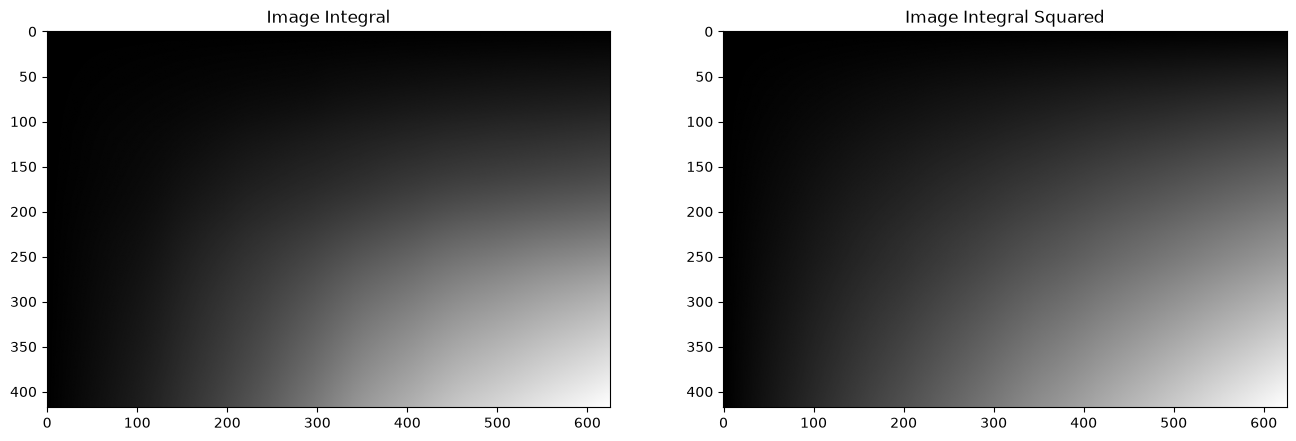

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

def image_integral( gray ) :
	### Put your code here ###
	# ...

	heigth, width = gray.shape[:2]
	I = gray.astype(np.int64)

    
	for i in range(1, heigth):
		for j in range(1, width):
			I[i, j] += (I[i, j-1] + I[i-1, j] - I[i-1, j-1])
			# print(I[i, j])

	return I

# fname = "/home/onejob/Desktop/2026.2/Visão Computacional/Atividades/A1/doc.png"
# fname = "/home/onejob/Desktop/2026.2/Visão Computacional/Atividades/images/cat1.jpg"
# fname = "images/rice.png"
# fname = "images/lena.ppm"
# fname = "images/coloredChips.png"

rgb = cv.cvtColor( cv.imread( fname ), cv.COLOR_BGR2RGB)
gray = cv.cvtColor(rgb, cv.COLOR_RGB2GRAY)
# img_rgb = np.full((1080, 1920 , 3), fill_value = 1, dtype=np.uint8)
# gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY);

I = image_integral(gray);
Isq = image_integral( np.array(gray)**2);
plt.figure( figsize=(16,16))
plt.subplot(1,2,1)
plt.imshow( I, cmap="gray");
plt.title("Image Integral");
plt.subplot(1,2,2)
plt.imshow( Isq, cmap="gray");
plt.title("Image Integral Squared");


**b)** Crie uma função que calcula a soma dos pixels de uma área retangular qualquer usando a imagem integral. A função deve receber uma imagem integral e uma lista contendo as coordenadas de uma região retangular com o seguinte formato: `x,y,nv`, sendo `x` e `y` indicando a posição do ponto central e `nv` a quantidade de vizinhos da janela em torno de `(x,y)`, de modo que a janela tenha dimensão `nv*2+1 x nv*2+1`. Com o uso da imagem integral, implemente as funções `mean` e ``variance` que calculam a média e a variância local de cada pixel e apresente os resultados para `nv=5`.

In [ ]:
def imint_sum_area( imint, x, y, nv ) :
	'''
	Função que recebe uma imagem integral e retorna a soma dos elementos da região retangular centrada em (x,y) com nv vizinhos
	parâmetros:
		imint: imagem integral
			x: coluna do ponto de referência
			y: linha do ponto de referência
			nv: número de vizinhos do ponto central que define a janela W de observação com dimensão (nv*2+1) x (nv*2+1)
	return:
		a soma dos elementos da janela W
	'''

	#### Put your code here ####
	#  ...

	i = x - nv 
	j = y - nv
	n = i + 2*nv+1
	m = j + 2*nv+1

	sum = 0

	for i in range(n):
		for j in range(m):
			sum += imint[i, j]

	return sum



def mean( imint, nv) :
	'''
	Função que aplica o filtro da média móvel
	parâmetros:
		 imint: imagem integral
			nv: número de vizinhos que forma a janela de vizinhança
	return:
		Retorna a imagem com o valor da média da vizinhança de cada pixel
	'''

	#### Put your code here ####
	#  ...

def variance( imint, imintsq, nv) :
	'''
	Função que aplica o filtro da variância móvel
	parâmetros:
		 	imint: imagem integral
		  imintsq: imagem integral do quadrado dos pixels da imagem original
			   nv: número de vizinhos que forma a janela de vizinhança
	return:
		Retorna a imagem com o valor da variância da vizinhança de cada pixel
	'''
	#### Put your code here ####
	#  ...


U = mean(I,5)
V = variance(I, Isq,5)
plt.figure(figsize=(16,16))
plt.subplot(121)
plt.imshow(U, cmap='gray');
plt.subplot(122)
plt.imshow(V, cmap='gray');


**c)** Implemente a limiarização adaptativa de Niblack usando imagem integral. O algoritmo de Niblack define um limiar local com base na média e na variância local do pixel observado. Seja $th(x,y,k)$ o limiar adaptativo do ponto $(x,y)$ definido como $th(x,y,k) = \mu +k\sigma$, onde $\mu$ é a média local do ponto, $\sigma$ o desvio padrão e $k$ um fator de ponderação do desvio padrão. Apresente a imagem binarizada para $nv=5$ e $k=0.5$.

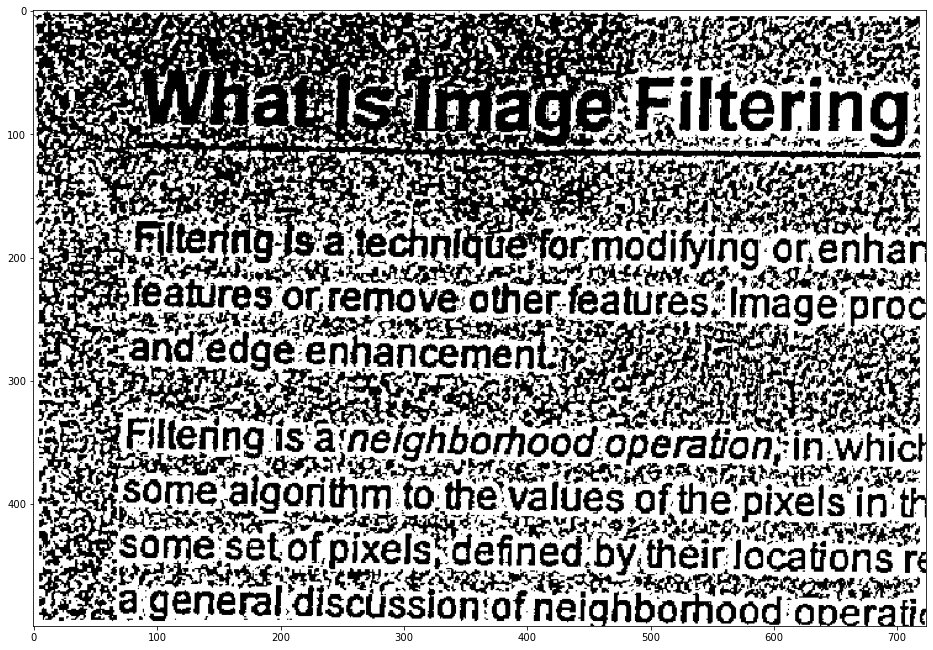

In [ ]:

def adaptive_threshold( img, imint, imintsq, nv, k ) :
	'''
	Binarização Adaptativa de Niblack
	Parâmetros:
		img: image original
		imint: imagem integral
		imintsq: imagem integral do quadrado dos pixels
		nv: quantidade de vizinhos
		k: peso do desvio padrão
	return:
		Uma imagem Binária [0,1]
	'''
	#### Put your code here ####
	#  ...

imint = image_integral(gray)
imintsq = image_integral(np.array(gray)**2)

BW = adaptive_threshold( gray, imint, imintsq, 5, 0.5 );
plt.figure( figsize=(16,16))
plt.imshow( BW, cmap='gray' );


**d)** Explique, usando exemplos, o efeito causado pela escolha de valores diferentes para $k$, considerando valores positivos e
também negativos.


**e)** Considere uma região dividida horizontalmente em duas partes:

```
+---------+---------+
|         |         |
|   +     |    -    |
|         |         |
+---------+---------+
```

Defina:

$$ F = S_{\text{esquerda}}-S_{\text{direita}} $$

Implemente a função:

```python
def haar_horizontal(integral, x, y, nv ):
    ...

```

A função deve calcular a característica utilizando somente a imagem integral, sem percorrer individualmente os pixels.
